# 02. Моделирование и сравнение авторегрессионных подходов

Цель ноутбука — смоделировать стохастическую компоненту температурного процесса в Волгограде после удаления детерминированной годовой сезонности.

Объектом моделирования является ряд температурных аномалий `target_anomaly`, полученный как отклонение фактической средней суточной температуры от климатической нормы. В этой постановке центральный интерес представляет не восстановление сезонного хода температуры, а анализ памяти случайного процесса и сравнение авторегрессионных спецификаций.

В исследовании есть три группы моделей:

- простые наивные правила задают базовые точки отсчёта;
- модели AR(p) являются основным статистическим инструментом исследования;
- RandomForest и нейросетевые архитектуры Dense, GRU и Conv1D используются как нелинейные бенчмарки для проверки того, остаются ли в ряде аномалий зависимости, которые не улавливаются линейной авторегрессией.

Итоговая цель — проверить, достаточно ли классического линейного авторегрессионного описания для рассматриваемого ряда температурных аномалий.

## Постановка задачи и защита от утечки информации

В работе рассматривается однодневный прогноз: для даты `t` нужно предсказать `target_anomaly`, используя только информацию, доступную не позже конца дня `t-1`. Это сохраняет причинную логику временного ряда и исключает использование будущих наблюдений.

Чтобы сравнение было честным и воспроизводимым, в проекте фиксируются:

- конечная дата массива данных;
- validation-интервал `2024-01-01 ... 2024-12-31`;
- test-интервал `2025-01-01 ... 2025-12-31`.

Во всех сценариях меняется только старт обучающего периода. Validation и test остаются одинаковыми для всех моделей и для всех сравнений.

Случайное перемешивание не используется. Лаговые и скользящие признаки построены по прошлым значениям температурных аномалий, а суточные метеорологические признаки в табличной модели дополнительно сдвигаются на один день назад.

In [1]:
from pathlib import Path
import os
import sys
import warnings

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.constants import (
    FIGURES_DIR,
    MODEL_DATASET_FILENAME,
    PROCESSED_DATA_DIR,
    TABLES_DIR,
)
from src.utils import (
    build_sequence_features,
    build_tabular_modeling_frame,
    build_train_scenarios,
    create_sequence_windows,
    ensure_project_directories,
    evaluate_forecast,
    forecast_autoreg_walk_forward,
    get_ar_lag_specifications,
    get_default_runtime_config,
    get_interval_summary,
    get_yearly_coverage,
    plot_acf_pacf,
    plot_rolling_mean_std,
    run_adf_test,
    seasonal_naive_forecast,
    select_autoreg_lag_models,
    set_global_seed,
    split_dataset_by_dates,
    split_sequence_windows_by_dates,
)

ensure_project_directories()
set_global_seed()
tf.get_logger().setLevel("ERROR")
runtime_config = get_default_runtime_config()

TARGET_COLUMN = "target_anomaly"
RAW_TARGET_COLUMN = "target_tavg"

I0000 00:00:1779646733.040399   10572 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779646741.291335   10572 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Шаг 1. Загрузка подготовленного датасета

Этот ноутбук предполагает, что файл `data/processed/volgograd_daily_temperature_dataset.csv` уже создан первым ноутбуком. Для воспроизводимости ниже дополнительно фиксируется конечная дата анализа: даже если в CSV окажутся более поздние строки, в эксперимент они не попадут.


In [2]:
dataset_path = PROCESSED_DATA_DIR / MODEL_DATASET_FILENAME
if not dataset_path.exists():
    raise FileNotFoundError(
        f"Файл {dataset_path} не найден. Сначала запустите notebooks/01_dataset_creation.ipynb."
    )

dataset_raw = (
    pd.read_csv(dataset_path, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)
dataset = (
    dataset_raw.loc[
        (dataset_raw["date"] >= runtime_config["data_start_date"])
        & (dataset_raw["date"] <= runtime_config["data_end_date"])
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Загружен файл: {dataset_path}")
print(
    "Период в исходном CSV: "
    f"{dataset_raw['date'].min().date()} ... {dataset_raw['date'].max().date()}"
)
print(
    "Период, используемый в исследовании: "
    f"{dataset['date'].min().date()} ... {dataset['date'].max().date()}"
)
print(f"Число строк после фиксации периода: {len(dataset):,}")
display(dataset.head())

required_columns = {
    "date",
    RAW_TARGET_COLUMN,
    "climatic_norm",
    TARGET_COLUMN,
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7",
    "rolling_std_14",
}

missing_columns = sorted(required_columns - set(dataset.columns))
if missing_columns:
    raise ValueError(
        "В подготовленном массиве данных отсутствуют столбцы, необходимые "
        f"для моделирования температурных аномалий: {missing_columns}. "
        "Сначала перезапустите notebooks/01_dataset_creation.ipynb."
    )

Загружен файл: /home/nochami/projects/0kursovaya/data/processed/volgograd_daily_temperature_dataset.csv
Период в исходном CSV: 2010-01-31 ... 2025-12-31
Период, используемый в исследовании: 2010-01-31 ... 2025-12-31
Число строк после фиксации периода: 5,813


,date,target_tavg,tmin,tmax,temp_range,prcp_sum,snow,pres_mean,wspd_mean,rhum_mean,tsun_sum,month,dayofyear,dayofweek,season,season_code,doy_sin,doy_cos,climatic_norm,target_anomaly,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_3,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_std_14
0,2010-01-31,-2.745833,-7.0,0.0,7.0,0.0,23,1020.550000,20.100000,99.166667,0,1,31,6,зима,0,0.508356,0.861147,-6.827381,4.081548,0.977704,-7.229542,-7.426436,-9.267262,-10.088690,5.008929,-4.559425,-5.589278,-8.038980,3.265233,3.427284
1,2010-02-01,-5.595652,-7.8,-3.9,3.9,0.0,23,1018.825000,23.550000,98.565217,0,2,32,0,зима,0,0.523094,0.852275,-5.928571,0.332919,4.081548,0.977704,-7.229542,-6.218841,-10.642560,4.857583,-0.723430,-3.682306,-7.026820,4.444322,4.649772
2,2010-02-02,-3.943478,-6.1,-2.0,4.1,0.0,23,1018.771429,18.782609,99.826087,0,2,33,1,зима,0,0.537677,0.843151,-5.101398,1.157919,0.332919,4.081548,0.977704,-4.741576,-10.035417,2.703734,1.797390,-2.746340,-6.242857,4.510502,4.911154
3,2010-02-03,-8.109091,-13.6,-6.0,7.6,0.0,23,1019.942857,36.654545,96.227273,0,2,34,2,зима,0,0.552101,0.833777,-4.934979,-3.174112,1.157919,0.332919,4.081548,-5.218996,-8.960417,-7.789053,1.857462,-1.903555,-5.443333,4.625258,5.151485
4,2010-02-04,-14.621739,-17.0,-11.8,5.2,0.0,23,1030.071429,47.895652,84.782609,0,2,35,3,зима,0,0.566362,0.824157,-4.336866,-10.284873,-3.174112,1.157919,0.332919,-7.426436,-10.799935,-7.221726,-0.561091,-1.611429,-5.030026,4.441900,5.079213


## Шаг 2. Проверка временного покрытия и сценарии длины train

Перед сравнением моделей полезно убедиться, что ранние годы действительно имеют достаточное покрытие. Для этого считаем число наблюдений по годам и строим несколько сценариев длины train.

В качестве самого длинного сценария берётся не просто максимально ранняя дата, а **максимум качественной истории**: самый ранний полный год до validation-периода, который проходит порог по полноте наблюдений.


In [3]:
coverage = get_yearly_coverage(dataset)
scenarios = build_train_scenarios(dataset)

scenario_rows = []
for scenario in scenarios:
    train_days = int((scenario["train_end"] - scenario["train_start"]).days + 1)
    scenario_rows.append(
        {
            "scenario": scenario["scenario"],
            "train_start": scenario["train_start"].date(),
            "train_end": scenario["train_end"].date(),
            "train_days": train_days,
            "train_years_approx": round(train_days / 365.25, 2),
            "description": scenario["description"],
        }
    )

scenarios_df = pd.DataFrame(scenario_rows)

coverage_path = TABLES_DIR / "02_yearly_coverage.csv"
scenarios_path = TABLES_DIR / "02_train_scenarios.csv"
coverage.to_csv(coverage_path, index=False)
scenarios_df.to_csv(scenarios_path, index=False)

display(Markdown("### Годовое покрытие датасета"))
display(coverage.round(3))

display(Markdown("### Сценарии длины обучающей истории"))
display(scenarios_df)

first_partial_year = coverage.loc[coverage["share_of_full_year"] < 0.98, "year"]
if not first_partial_year.empty:
    print(
        "Самые ранние частично заполненные годы не используются как старт максимального train, "
        "если они не проходят порог полноты."
    )

print(f"Таблица покрытия сохранена в: {coverage_path}")
print(f"Таблица сценариев сохранена в: {scenarios_path}")


### Годовое покрытие датасета

,year,rows,days_in_year,share_of_full_year
0,2010,335,365,0.918
1,2011,365,365,1.000
2,2012,366,366,1.000
3,2013,365,365,1.000
4,2014,364,365,0.997
5,2015,365,365,1.000
6,2016,366,366,1.000
7,2017,365,365,1.000
8,2018,365,365,1.000
9,2019,365,365,1.000


### Сценарии длины обучающей истории

,scenario,train_start,train_end,train_days,train_years_approx,description
0,Максимум качественной истории,2011-01-01,2023-12-31,4748,13.0,Самая ранняя доступная полная история после пр...
1,Длинная история,2014-01-01,2023-12-31,3652,10.0,История длиной примерно 10 лет
2,Средняя история,2018-01-01,2023-12-31,2191,6.0,История длиной примерно 6 лет
3,Короткая история,2021-01-01,2023-12-31,1095,3.0,История длиной примерно 3 лет


Самые ранние частично заполненные годы не используются как старт максимального train, если они не проходят порог полноты.
Таблица покрытия сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_yearly_coverage.csv
Таблица сценариев сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_train_scenarios.csv


## Шаг 3. Подготовка признаков для разных классов моделей

В проекте используются два представления данных:

- **табличное** — для простых ориентиров, статистической модели, `RandomForest` и `Dense`-сети; здесь применяются лаги, скользящие статистики и календарные признаки;
- **последовательностное** — для `GRU` и `Conv1D`; здесь модель получает окно из последних 30 дней и учится извлекать динамику из последовательности.

Базовые и авторегрессионные модели нужны как проверяемые статистические точки отсчёта: без них нельзя понять, действительно ли более сложная модель использует структуру ряда лучше простого сезонного правила. Нейросети в этом сравнении применяются к тем же данным, но получают более гибкий способ связывать прошлые значения, сезонность и прогноз.


In [4]:
tabular_df, feature_columns, weather_columns = build_tabular_modeling_frame(dataset)
sequence_feature_columns = build_sequence_features(dataset)
X_sequence, y_sequence, sequence_dates = create_sequence_windows(
    dataset,
    sequence_feature_columns,
    window_size=runtime_config["sequence_window_days"],
)

scenario_lookup = {scenario["scenario"]: scenario for scenario in scenarios}
main_scenario = scenario_lookup["Максимум качественной истории"]

train_df, validation_df, test_df = split_dataset_by_dates(
    tabular_df,
    train_start=main_scenario["train_start"],
    validation_start=runtime_config["validation_start_date"],
    validation_end=runtime_config["validation_end_date"],
    test_start=runtime_config["test_start_date"],
    test_end=runtime_config["test_end_date"],
)

sequence_main = split_sequence_windows_by_dates(
    X_sequence,
    y_sequence,
    sequence_dates,
    train_start=main_scenario["train_start"],
    validation_start=runtime_config["validation_start_date"],
    validation_end=runtime_config["validation_end_date"],
    test_start=runtime_config["test_start_date"],
    test_end=runtime_config["test_end_date"],
)

validation_sequence_dates = pd.Series(pd.to_datetime(sequence_main["dates_validation"]))
test_sequence_dates = pd.Series(pd.to_datetime(sequence_main["dates_test"]))

if not validation_df["date"].reset_index(drop=True).equals(validation_sequence_dates):
    raise ValueError(
        "Даты validation для табличного и последовательностного представления не совпали."
    )
if not test_df["date"].reset_index(drop=True).equals(test_sequence_dates):
    raise ValueError(
        "Даты test для табличного и последовательностного представления не совпали."
    )

interval_summary = pd.DataFrame(
    [
        get_interval_summary(train_df, "train"),
        get_interval_summary(validation_df, "validation"),
        get_interval_summary(test_df, "test"),
    ]
)

display(Markdown("### Интервалы для основного сценария"))
display(interval_summary)

print(f"Число табличных признаков: {len(feature_columns)}")
print(f"Число последовательностных признаков: {len(sequence_feature_columns)}")
print(
    f"Размер последовательностных окон: {runtime_config['sequence_window_days']} дней"
)
print("Табличные признаки:")
print(feature_columns)
print("Последовательностные признаки:")
print(sequence_feature_columns)


### Интервалы для основного сценария

,subset,rows,start_date,end_date
0,train,4747,2011-01-01,2023-12-31
1,validation,366,2024-01-01,2024-12-31
2,test,365,2025-01-01,2025-12-31


Число табличных признаков: 26
Число последовательностных признаков: 11
Размер последовательностных окон: 30 дней
Табличные признаки:
['month', 'dayofyear', 'dayofweek', 'season_code', 'doy_sin', 'doy_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'rolling_std_14', 'tmin_lag1', 'tmax_lag1', 'temp_range_lag1', 'prcp_sum_lag1', 'snow_lag1', 'pres_mean_lag1', 'wspd_mean_lag1', 'rhum_mean_lag1', 'tsun_sum_lag1']
Последовательностные признаки:
['target_anomaly', 'tmin', 'tmax', 'temp_range', 'prcp_sum', 'snow', 'pres_mean', 'wspd_mean', 'rhum_mean', 'doy_sin', 'doy_cos']


## Предварительный анализ ряда температурных аномалий

После удаления детерминированной годовой сезонности объектом моделирования становится ряд температурных аномалий `target_anomaly`. Он интерпретируется как стохастическая компонента исходного температурного процесса.

На этом этапе используется только train-период основного сценария. Validation- и test-интервалы не участвуют ни в проверке стационарности, ни в предварительном выборе авторегрессионных спецификаций.

Тест Дики — Фуллера применяется к ряду `target_anomaly` для проверки гипотезы о единичном корне. Графики автокорреляционной и частичной автокорреляционной функций используются для анализа памяти процесса и содержательного выбора лагов в моделях AR(p).

### Проверка стационарности ряда температурных аномалий

,series,observations,used_lag,adf_statistic,p_value,critical_value_1pct,critical_value_5pct,critical_value_10pct,stationary_at_5pct
0,target_anomaly_train,4743,3,-19.3147,0.0,-3.4317,-2.8621,-2.5671,True


График автокорреляции и частичной автокорреляции сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_acf_pacf_anomaly.png
График скользящих характеристик сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_rolling_mean_std_anomaly.png
Таблица проверки стационарности сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_adf_stationarity_anomaly.csv


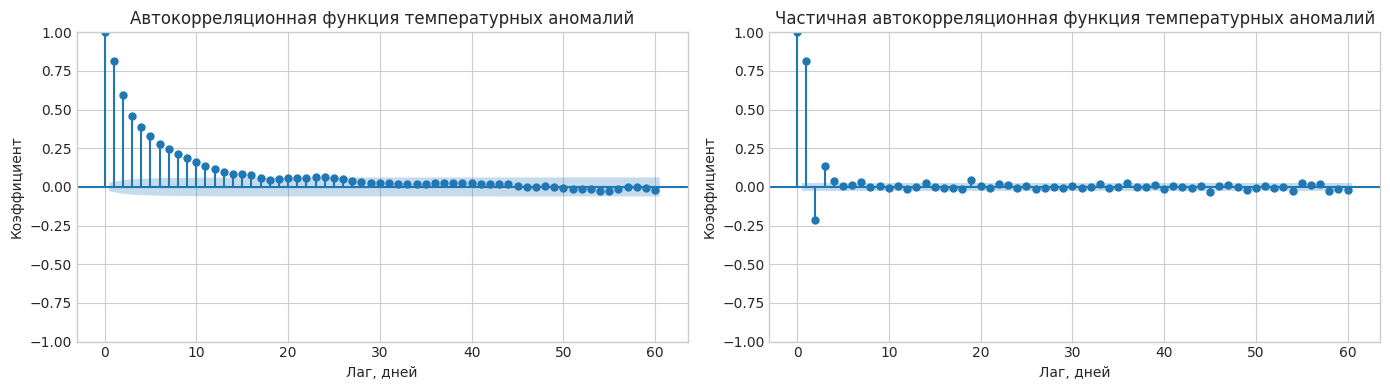

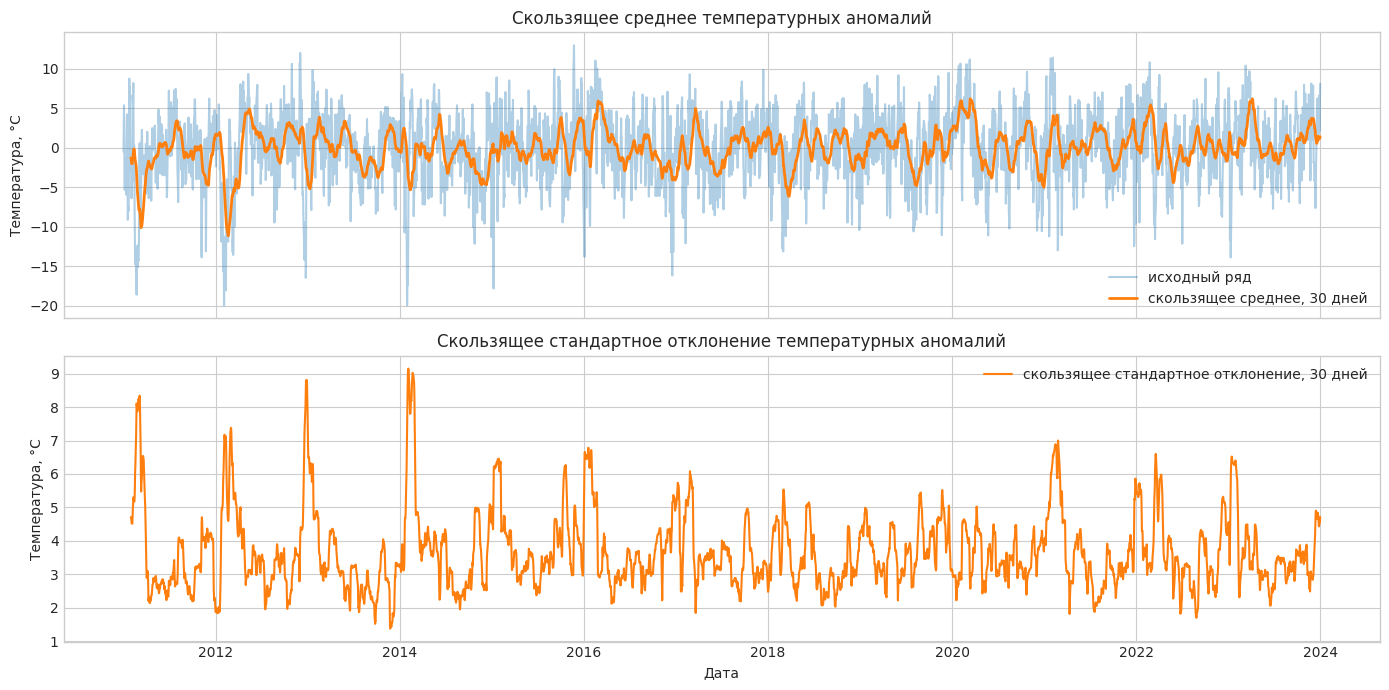

In [5]:
train_anomaly_series = train_df.set_index("date")[TARGET_COLUMN].dropna().astype(float)

if train_anomaly_series.empty:
    raise ValueError("В train-интервале отсутствуют наблюдения target_anomaly.")

acf_pacf_path = FIGURES_DIR / "02_acf_pacf_anomaly.png"
rolling_stats_path = FIGURES_DIR / "02_rolling_mean_std_anomaly.png"
adf_stationarity_path = TABLES_DIR / "02_adf_stationarity_anomaly.csv"

plot_acf_pacf(train_anomaly_series, acf_pacf_path, lags=60)
plot_rolling_mean_std(train_anomaly_series, rolling_stats_path, window=30)

adf_stationarity = run_adf_test(train_anomaly_series, "target_anomaly_train")
adf_stationarity.to_csv(adf_stationarity_path, index=False)

display(Markdown("### Проверка стационарности ряда температурных аномалий"))
display(adf_stationarity.round(4))

print(f"График автокорреляции и частичной автокорреляции сохранён в: {acf_pacf_path}")
print(f"График скользящих характеристик сохранён в: {rolling_stats_path}")
print(f"Таблица проверки стационарности сохранена в: {adf_stationarity_path}")

## Выбор лагов для авторегрессионных моделей

После предварительного анализа проверим несколько наборов лагов. Они отражают разную память ряда: один день, неделю, месяц, короткую группу лагов и годовой сезонный лаг.

`AIC` и `BIC` используются как дополнительные статистические критерии качества подгонки на обучающем периоде. Итоговое сравнение моделей всё равно проводится по ошибкам прогноза на validation и test.


In [6]:
ar_lag_specs = get_ar_lag_specifications()
ar_lag_selection_path = TABLES_DIR / "02_ar_lag_selection_anomaly.csv"

ar_lag_selection = select_autoreg_lag_models(train_anomaly_series, ar_lag_specs)
ar_lag_selection.to_csv(ar_lag_selection_path, index=False)

display(Markdown("### Сравнение авторегрессионных спецификаций на train-ряде аномалий"))
display(ar_lag_selection.round(3))

print(f"Таблица выбора авторегрессионных лагов сохранена в: {ar_lag_selection_path}")

### Сравнение авторегрессионных спецификаций на train-ряде аномалий

,model,lags,aic,bic,nobs,status
0,AR(1),1,22419.941,22439.337,4746,ok
1,AR(7),7,27341.512,27360.904,4740,ok
2,AR(30),30,27490.176,27509.553,4717,ok
3,AR с короткими лагами,"1, 2, 3, 7, 14, 30",21940.654,21992.325,4717,ok
4,AR с сезонным лагом,"1, 2, 3, 7, 14, 30, 365",20430.835,20488.303,4382,ok


Таблица выбора авторегрессионных лагов сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_ar_lag_selection_anomaly.csv


## Протокол оценки авторегрессионных моделей

Авторегрессионные прогнозы строятся последовательно по одному дню. Для прогноза на день `t` используются только наблюдения до дня `t`; после проверки прогноза фактическое значение дня `t` добавляется в историю и может использоваться для следующего дня.

Такой протокол делает авторегрессионные модели сопоставимыми с моделями, которые используют лаговые признаки и окна временного ряда.


## Шаг 4. Метрики и набор сравниваемых моделей

В исследовании используются метрики `MAE`, `RMSE`, `MASE` и `bias`, потому что они описывают разные стороны ошибки прогноза временного ряда.

- `MAE` удобна как средняя абсолютная ошибка в градусах Цельсия.
- `RMSE` сильнее штрафует крупные промахи.
- `MASE` нормирует ошибку относительно сезонного наивного масштаба и показывает, насколько модель лучше или хуже простой сезонной точки отсчёта.
- `bias` показывает систематическое завышение или занижение прогноза, что важно для анализа смещения модели.

`MAPE` здесь не используется как основная метрика, потому что температура в градусах Цельсия может быть близка к нулю или отрицательной, а это делает процентную ошибку плохо интерпретируемой.

Состав моделей:

- `Naive (t-1)`;
- `Seasonal naive (t-365)`;
- `AR(1)`, `AR(7)`, `AR(30)` как простые авторегрессионные модели с одним лагом;
- `AR с короткими лагами` для лагов 1, 2, 3, 7, 14 и 30;
- `AR с сезонным лагом` для коротких лагов и лага 365;
- `RandomForestRegressor` как вспомогательная табличная модель для сравнения;
- `Dense-сеть` по лаговым и календарным признакам;
- `GRU` по окнам временного ряда;
- `Conv1D` по тем же окнам временного ряда.

Холт без сезонной компоненты исключён из центрального сравнения: для температурного ряда с выраженной годовой сезонностью такая модель даёт методически слабую базу и на предварительной проверке давала выраженное систематическое смещение.


In [7]:
def build_tabular_pipeline():
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "regressor",
                RandomForestRegressor(
                    n_estimators=220,
                    max_depth=12,
                    min_samples_leaf=2,
                    random_state=runtime_config["random_state"],
                    n_jobs=-1,
                ),
            ),
        ]
    )


def temporal_tail_split(X, y, validation_share=0.15):
    split_index = int(len(X) * (1 - validation_share))
    if split_index <= 0 or split_index >= len(X):
        raise ValueError(
            "Не удалось выделить внутреннюю валидацию из обучающего интервала."
        )

    if hasattr(X, "iloc"):
        X_fit, X_valid = X.iloc[:split_index], X.iloc[split_index:]
    else:
        X_fit, X_valid = X[:split_index], X[split_index:]

    if hasattr(y, "iloc"):
        y_fit, y_valid = y.iloc[:split_index], y.iloc[split_index:]
    else:
        y_fit, y_valid = y[:split_index], y[split_index:]

    return X_fit, X_valid, y_fit, y_valid


def prepare_dense_matrices(X_fit, X_valid, X_predict=None):
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_fit_ready = scaler.fit_transform(imputer.fit_transform(X_fit))
    X_valid_ready = scaler.transform(imputer.transform(X_valid))
    X_predict_ready = (
        None if X_predict is None else scaler.transform(imputer.transform(X_predict))
    )

    return X_fit_ready, X_valid_ready, X_predict_ready, imputer, scaler


def build_dense_model(input_dim):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(input_dim,)),
            keras.layers.Dense(48, activation="relu"),
            keras.layers.Dropout(0.15),
            keras.layers.Dense(24, activation="relu"),
            keras.layers.Dense(1),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mae",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


def build_gru_model(input_shape):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=input_shape),
            keras.layers.GRU(24),
            keras.layers.Dense(12, activation="relu"),
            keras.layers.Dense(1),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mae",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


def build_conv1d_model(input_shape):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=input_shape),
            keras.layers.Conv1D(24, kernel_size=3, activation="relu", padding="causal"),
            keras.layers.Conv1D(24, kernel_size=3, activation="relu", padding="causal"),
            keras.layers.GlobalAveragePooling1D(),
            keras.layers.Dense(12, activation="relu"),
            keras.layers.Dense(1),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mae",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


def fit_dense_network(X_fit, y_fit, X_valid, y_valid):
    set_global_seed(runtime_config["random_state"])
    tf.keras.backend.clear_session()

    X_fit_ready, X_valid_ready, _, imputer, scaler = prepare_dense_matrices(
        X_fit, X_valid
    )
    model = build_dense_model(X_fit_ready.shape[1])
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=runtime_config["neural_patience"],
            restore_best_weights=True,
        )
    ]
    history = model.fit(
        X_fit_ready,
        np.asarray(y_fit, dtype=float),
        validation_data=(X_valid_ready, np.asarray(y_valid, dtype=float)),
        epochs=runtime_config["neural_epochs"],
        batch_size=runtime_config["neural_batch_size"],
        verbose=0,
        callbacks=callbacks,
    )
    return {
        "model": model,
        "imputer": imputer,
        "scaler": scaler,
        "history": history,
    }


def predict_dense_network(artifacts, X_predict):
    X_ready = artifacts["scaler"].transform(artifacts["imputer"].transform(X_predict))
    return artifacts["model"].predict(X_ready, verbose=0).reshape(-1)


def scale_sequence_arrays(X_fit, X_valid, X_predict=None):
    mean = X_fit.mean(axis=(0, 1), keepdims=True)
    std = X_fit.std(axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-6, 1.0, std)

    X_fit_ready = (X_fit - mean) / std
    X_valid_ready = (X_valid - mean) / std
    X_predict_ready = None if X_predict is None else (X_predict - mean) / std

    return X_fit_ready, X_valid_ready, X_predict_ready, {"mean": mean, "std": std}


def fit_sequence_network(model_builder, X_fit, y_fit, X_valid, y_valid):
    set_global_seed(runtime_config["random_state"])
    tf.keras.backend.clear_session()

    X_fit_ready, X_valid_ready, _, scaling = scale_sequence_arrays(X_fit, X_valid)
    model = model_builder(X_fit_ready.shape[1:])
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=runtime_config["neural_patience"],
            restore_best_weights=True,
        )
    ]
    history = model.fit(
        X_fit_ready,
        np.asarray(y_fit, dtype=float),
        validation_data=(X_valid_ready, np.asarray(y_valid, dtype=float)),
        epochs=runtime_config["neural_epochs"],
        batch_size=runtime_config["neural_batch_size"],
        verbose=0,
        callbacks=callbacks,
    )
    return {
        "model": model,
        "scaling": scaling,
        "history": history,
    }


def predict_sequence_network(artifacts, X_predict):
    mean = artifacts["scaling"]["mean"]
    std = artifacts["scaling"]["std"]
    X_ready = (X_predict - mean) / std
    return artifacts["model"].predict(X_ready, verbose=0).reshape(-1)


ar_forecast_check_records = []


def build_autoreg_predictions(
    history_series, target_series, target_dates, lag_specs, split_label
):
    predictions = {}
    expected_dates = pd.to_datetime(pd.Series(target_dates)).reset_index(drop=True)
    for spec in lag_specs:
        model_name = spec["model"]
        try:
            forecast_values = forecast_autoreg_walk_forward(
                history_series, target_series, spec["lags"]
            )
            forecast_series = pd.Series(
                forecast_values, index=expected_dates, name=model_name
            )
            dates_match = forecast_series.index.equals(pd.DatetimeIndex(expected_dates))
            finite_predictions = int(
                np.isfinite(forecast_series.to_numpy(dtype=float)).sum()
            )
            status = (
                "ok"
                if len(forecast_series) == len(expected_dates)
                and dates_match
                and finite_predictions > 0
                else "check_failed"
            )
            predictions[model_name] = forecast_series.to_numpy(dtype=float)
        except Exception as exc:
            forecast_series = pd.Series(dtype=float)
            finite_predictions = 0
            status = str(exc)
            print(f"  {model_name}: модель пропущена ({exc})", flush=True)

        ar_forecast_check_records.append(
            {
                "split": split_label,
                "model": model_name,
                "expected_rows": int(len(expected_dates)),
                "predicted_rows": int(len(forecast_series)),
                "finite_predictions": int(finite_predictions),
                "status": status,
            }
        )

    return predictions


def evaluate_prediction_dict(y_true, prediction_dict, insample):
    metrics = pd.DataFrame(
        [
            evaluate_forecast(y_true, prediction, model_name, insample=insample)
            for model_name, prediction in prediction_dict.items()
        ]
    )
    return metrics.sort_values(["mae", "rmse"]).reset_index(drop=True)


def build_prediction_frame(reference_df, prediction_dict):
    base_columns = ["date", TARGET_COLUMN, RAW_TARGET_COLUMN, "season"]
    base_columns = [column for column in base_columns if column in reference_df.columns]
    frame = reference_df[base_columns].reset_index(drop=True).copy()
    for model_name, prediction in prediction_dict.items():
        frame[model_name] = np.asarray(prediction, dtype=float)
    return frame


def run_scenario_experiment(scenario, include_conv1d=False, return_histories=False):
    train_tab, validation_tab, test_tab = split_dataset_by_dates(
        tabular_df,
        train_start=scenario["train_start"],
        validation_start=runtime_config["validation_start_date"],
        validation_end=runtime_config["validation_end_date"],
        test_start=runtime_config["test_start_date"],
        test_end=runtime_config["test_end_date"],
    )

    sequence_split = split_sequence_windows_by_dates(
        X_sequence,
        y_sequence,
        sequence_dates,
        train_start=scenario["train_start"],
        validation_start=runtime_config["validation_start_date"],
        validation_end=runtime_config["validation_end_date"],
        test_start=runtime_config["test_start_date"],
        test_end=runtime_config["test_end_date"],
    )

    validation_dates_sequence = pd.Series(
        pd.to_datetime(sequence_split["dates_validation"])
    )
    test_dates_sequence = pd.Series(pd.to_datetime(sequence_split["dates_test"]))
    if not train_tab["date"].is_monotonic_increasing:
        raise ValueError("Train-интервал должен быть отсортирован по времени.")
    if (
        not validation_tab["date"]
        .reset_index(drop=True)
        .equals(validation_dates_sequence)
    ):
        raise ValueError(
            f"В сценарии {scenario['scenario']} не совпали validation-даты."
        )
    if not test_tab["date"].reset_index(drop=True).equals(test_dates_sequence):
        raise ValueError(f"В сценарии {scenario['scenario']} не совпали test-даты.")

    X_train = train_tab[feature_columns]
    y_train = train_tab[TARGET_COLUMN]
    X_validation = validation_tab[feature_columns]
    y_validation = validation_tab[TARGET_COLUMN]
    X_test = test_tab[feature_columns]
    y_test = test_tab[TARGET_COLUMN]

    validation_predictions = {
        "Naive (t-1)": validation_tab["lag_1"].to_numpy(),
        "Seasonal naive (t-365)": seasonal_naive_forecast(
            validation_tab["date"],
            train_tab.set_index("date")[TARGET_COLUMN],
        ).to_numpy(),
    }
    validation_predictions.update(
        build_autoreg_predictions(
            y_train,
            y_validation,
            validation_tab["date"],
            ar_lag_specs,
            f"{scenario['scenario']} validation",
        )
    )

    print(f"  {scenario['scenario']}: validation -> RandomForest", flush=True)
    tabular_model = build_tabular_pipeline()
    tabular_model.fit(X_train, y_train)
    validation_predictions["RandomForest"] = tabular_model.predict(X_validation)

    print(f"  {scenario['scenario']}: validation -> Dense-сеть", flush=True)
    dense_artifacts = fit_dense_network(X_train, y_train, X_validation, y_validation)
    validation_predictions["Dense-сеть"] = predict_dense_network(
        dense_artifacts, X_validation
    )

    print(f"  {scenario['scenario']}: validation -> GRU", flush=True)
    gru_artifacts = fit_sequence_network(
        build_gru_model,
        sequence_split["X_train"],
        sequence_split["y_train"],
        sequence_split["X_validation"],
        sequence_split["y_validation"],
    )
    validation_predictions["GRU"] = predict_sequence_network(
        gru_artifacts, sequence_split["X_validation"]
    )

    conv_artifacts = None
    if include_conv1d:
        print(f"  {scenario['scenario']}: validation -> Conv1D", flush=True)
        conv_artifacts = fit_sequence_network(
            build_conv1d_model,
            sequence_split["X_train"],
            sequence_split["y_train"],
            sequence_split["X_validation"],
            sequence_split["y_validation"],
        )
        validation_predictions["Conv1D"] = predict_sequence_network(
            conv_artifacts, sequence_split["X_validation"]
        )

    validation_metrics = evaluate_prediction_dict(
        y_validation, validation_predictions, insample=y_train
    )
    validation_metrics["scenario"] = scenario["scenario"]

    full_train_tab = pd.concat([train_tab, validation_tab], ignore_index=True)
    X_full_train = full_train_tab[feature_columns]
    y_full_train = full_train_tab[TARGET_COLUMN]

    test_predictions = {
        "Naive (t-1)": test_tab["lag_1"].to_numpy(),
        "Seasonal naive (t-365)": seasonal_naive_forecast(
            test_tab["date"],
            full_train_tab.set_index("date")[TARGET_COLUMN],
        ).to_numpy(),
    }
    test_predictions.update(
        build_autoreg_predictions(
            y_full_train,
            y_test,
            test_tab["date"],
            ar_lag_specs,
            f"{scenario['scenario']} test",
        )
    )

    print(f"  {scenario['scenario']}: test -> RandomForest", flush=True)
    final_tabular_model = build_tabular_pipeline()
    final_tabular_model.fit(X_full_train, y_full_train)
    test_predictions["RandomForest"] = final_tabular_model.predict(X_test)

    X_dense_fit, X_dense_valid, y_dense_fit, y_dense_valid = temporal_tail_split(
        X_full_train, y_full_train
    )
    print(f"  {scenario['scenario']}: test -> Dense-сеть", flush=True)
    final_dense_artifacts = fit_dense_network(
        X_dense_fit, y_dense_fit, X_dense_valid, y_dense_valid
    )
    test_predictions["Dense-сеть"] = predict_dense_network(
        final_dense_artifacts, X_test
    )

    X_sequence_full_train = np.concatenate(
        [sequence_split["X_train"], sequence_split["X_validation"]],
        axis=0,
    )
    y_sequence_full_train = np.concatenate(
        [sequence_split["y_train"], sequence_split["y_validation"]],
        axis=0,
    )
    X_seq_fit, X_seq_valid, y_seq_fit, y_seq_valid = temporal_tail_split(
        X_sequence_full_train,
        y_sequence_full_train,
    )

    print(f"  {scenario['scenario']}: test -> GRU", flush=True)
    final_gru_artifacts = fit_sequence_network(
        build_gru_model,
        X_seq_fit,
        y_seq_fit,
        X_seq_valid,
        y_seq_valid,
    )
    test_predictions["GRU"] = predict_sequence_network(
        final_gru_artifacts, sequence_split["X_test"]
    )

    final_conv_artifacts = None
    if include_conv1d:
        print(f"  {scenario['scenario']}: test -> Conv1D", flush=True)
        final_conv_artifacts = fit_sequence_network(
            build_conv1d_model,
            X_seq_fit,
            y_seq_fit,
            X_seq_valid,
            y_seq_valid,
        )
        test_predictions["Conv1D"] = predict_sequence_network(
            final_conv_artifacts, sequence_split["X_test"]
        )

    test_metrics = evaluate_prediction_dict(
        y_test, test_predictions, insample=y_full_train
    )
    test_metrics["scenario"] = scenario["scenario"]

    histories = {}
    if return_histories:
        histories = {
            "Dense-сеть": dense_artifacts["history"],
            "GRU": gru_artifacts["history"],
        }
        if include_conv1d and conv_artifacts is not None:
            histories["Conv1D"] = conv_artifacts["history"]

    print(f"  {scenario['scenario']}: сценарий завершён", flush=True)
    return {
        "scenario": scenario,
        "train_frame": train_tab,
        "validation_frame": validation_tab,
        "test_frame": test_tab,
        "validation_metrics": validation_metrics,
        "test_metrics": test_metrics,
        "validation_predictions": build_prediction_frame(
            validation_tab, validation_predictions
        ),
        "test_predictions": build_prediction_frame(test_tab, test_predictions),
        "histories": histories,
    }


## Шаг 5. Эксперимент: как меняется качество при разной длине train

Ниже все модели сравниваются на одном и том же validation- и test-интервале. Меняется только старт train-периода.

Состав моделей:

- `Naive (t-1)` и `Seasonal naive (t-365)` используются как простые точки отсчёта;
- `AR(1)`, `AR(7)`, `AR(30)` задают базовые авторегрессионные спецификации;
- `AR с короткими лагами` использует лаги 1, 2, 3, 7, 14 и 30;
- `AR с сезонным лагом` проверяет, остаётся ли в ряде аномалий годовая зависимость после удаления климатической нормы;
- `RandomForestRegressor`, `Dense-сеть`, `GRU` и `Conv1D` используются как нелинейные бенчмарки. Их роль — не заменить авторегрессионный анализ, а проверить, дают ли более гибкие модели существенное улучшение по сравнению с AR(p).


In [8]:
scenario_order = [
    label
    for label in [
        "Короткая история",
        "Средняя история",
        "Длинная история",
        "Максимум качественной истории",
    ]
    if label in scenario_lookup
]

scenario_results = {}
for scenario_name in scenario_order:
    scenario = scenario_lookup[scenario_name]
    print(
        "Запуск сценария: "
        f"{scenario_name} ({scenario['train_start'].date()} ... {scenario['train_end'].date()})"
    )
    scenario_results[scenario_name] = run_scenario_experiment(
        scenario,
        include_conv1d=False,
        return_histories=False,
    )

validation_by_train = pd.concat(
    [scenario_results[name]["validation_metrics"] for name in scenario_order],
    ignore_index=True,
)
test_by_train = pd.concat(
    [scenario_results[name]["test_metrics"] for name in scenario_order],
    ignore_index=True,
)

scenario_meta = scenarios_df.set_index("scenario")[
    ["train_start", "train_years_approx"]
]
for metrics_frame in [validation_by_train, test_by_train]:
    metrics_frame["train_start"] = metrics_frame["scenario"].map(
        scenario_meta["train_start"]
    )
    metrics_frame["train_years_approx"] = metrics_frame["scenario"].map(
        scenario_meta["train_years_approx"]
    )

validation_by_train_path = TABLES_DIR / "02_train_size_validation_metrics.csv"
test_by_train_path = TABLES_DIR / "02_train_size_test_metrics.csv"
ar_forecast_checks_path = TABLES_DIR / "02_ar_forecast_checks.csv"
validation_by_train.to_csv(validation_by_train_path, index=False)
test_by_train.to_csv(test_by_train_path, index=False)
ar_forecast_checks = pd.DataFrame(ar_forecast_check_records)
ar_forecast_checks.to_csv(ar_forecast_checks_path, index=False)

validation_pivot = (
    validation_by_train.pivot(index="model", columns="scenario", values="mae")
    .reindex(columns=scenario_order)
    .sort_index()
)
test_pivot = (
    test_by_train.pivot(index="model", columns="scenario", values="mae")
    .reindex(columns=scenario_order)
    .sort_index()
)

display(Markdown("### MAE на validation при разной длине train"))
display(validation_pivot.round(3))

display(Markdown("### MAE на test при разной длине train"))
display(test_pivot.round(3))

display(Markdown("### Проверка авторегрессионных прогнозов"))
display(ar_forecast_checks)

print(f"Validation-метрики по сценариям сохранены в: {validation_by_train_path}")
print(f"Test-метрики по сценариям сохранены в: {test_by_train_path}")
print(f"Проверки авторегрессионных прогнозов сохранены в: {ar_forecast_checks_path}")


Запуск сценария: Короткая история (2021-01-01 ... 2023-12-31)
  Короткая история: validation -> RandomForest
  Короткая история: validation -> Dense-сеть


E0000 00:00:1779646762.417069   10572 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  Короткая история: validation -> GRU
  Короткая история: test -> RandomForest
  Короткая история: test -> Dense-сеть
  Короткая история: test -> GRU
  Короткая история: сценарий завершён
Запуск сценария: Средняя история (2018-01-01 ... 2023-12-31)
  Средняя история: validation -> RandomForest
  Средняя история: validation -> Dense-сеть
  Средняя история: validation -> GRU
  Средняя история: test -> RandomForest
  Средняя история: test -> Dense-сеть
  Средняя история: test -> GRU
  Средняя история: сценарий завершён
Запуск сценария: Длинная история (2014-01-01 ... 2023-12-31)
  Длинная история: validation -> RandomForest
  Длинная история: validation -> Dense-сеть
  Длинная история: validation -> GRU
  Длинная история: test -> RandomForest
  Длинная история: test -> Dense-сеть
  Длинная история: test -> GRU
  Длинная история: сценарий завершён
Запуск сценария: Максимум качественной истории (2011-01-01 ... 2023-12-31)
  Максимум качественной истории: validation -> RandomForest
  Максиму

### MAE на validation при разной длине train

scenario,Короткая история,Средняя история,Длинная история,Максимум качественной истории
model,,,,
AR с короткими лагами,1.943,1.948,1.951,1.957
AR с сезонным лагом,1.951,1.946,1.955,1.959
AR(1),2.011,2.014,2.019,2.025
AR(30),3.390,3.418,3.471,3.510
AR(7),3.312,3.332,3.367,3.382
Dense-сеть,2.015,1.894,1.920,1.919
GRU,1.912,1.876,1.854,1.866
Naive (t-1),2.141,2.141,2.141,2.141
RandomForest,2.008,2.002,2.011,1.972


### MAE на test при разной длине train

scenario,Короткая история,Средняя история,Длинная история,Максимум качественной истории
model,,,,
AR с короткими лагами,1.899,1.896,1.893,1.888
AR с сезонным лагом,1.896,1.893,1.897,1.893
AR(1),1.934,1.937,1.940,1.935
AR(30),3.726,3.761,3.815,3.856
AR(7),3.597,3.602,3.630,3.629
Dense-сеть,1.863,1.830,1.811,1.791
GRU,1.813,1.810,1.759,1.823
Naive (t-1),1.946,1.946,1.946,1.946
RandomForest,1.935,1.896,1.848,1.831


### Проверка авторегрессионных прогнозов

,split,model,expected_rows,predicted_rows,finite_predictions,status
0,Короткая история validation,AR(1),366,366,366,ok
1,Короткая история validation,AR(7),366,366,366,ok
2,Короткая история validation,AR(30),366,366,366,ok
3,Короткая история validation,AR с короткими лагами,366,366,366,ok
4,Короткая история validation,AR с сезонным лагом,366,366,366,ok
5,Короткая история test,AR(1),365,365,365,ok
6,Короткая история test,AR(7),365,365,365,ok
7,Короткая история test,AR(30),365,365,365,ok
8,Короткая история test,AR с короткими лагами,365,365,365,ok
9,Короткая история test,AR с сезонным лагом,365,365,365,ok


Validation-метрики по сценариям сохранены в: /home/nochami/projects/0kursovaya/outputs/tables/02_train_size_validation_metrics.csv
Test-метрики по сценариям сохранены в: /home/nochami/projects/0kursovaya/outputs/tables/02_train_size_test_metrics.csv
Проверки авторегрессионных прогнозов сохранены в: /home/nochami/projects/0kursovaya/outputs/tables/02_ar_forecast_checks.csv


## Шаг 6. Анализ влияния длины обучающей истории

Отдельно посмотрим, как меняется `MAE` по мере роста train-истории и как меняется разрыв между вспомогательной табличной моделью `RandomForest` и лучшими нейросетями.


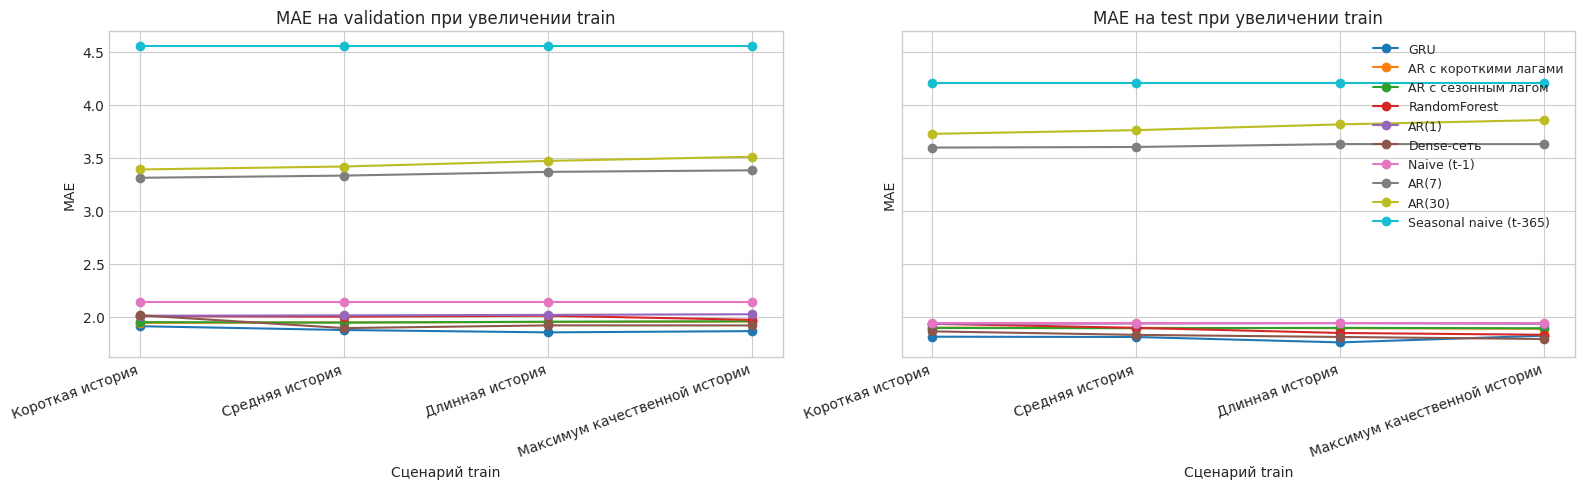

### Как меняется разрыв между лучшей нейросетью и RandomForest на test

model,scenario,AR с короткими лагами,AR с сезонным лагом,AR(1),AR(30),AR(7),Dense-сеть,GRU,Naive (t-1),RandomForest,Seasonal naive (t-365),Лучшая нейросеть,Лучший нейросетевой MAE,Преимущество лучшей нейросети над RandomForest
0,Короткая история,1.899,1.896,1.934,3.726,3.597,1.863,1.813,1.946,1.935,4.203,GRU,1.813,-0.122
1,Средняя история,1.896,1.893,1.937,3.761,3.602,1.830,1.810,1.946,1.896,4.203,GRU,1.810,-0.086
2,Длинная история,1.893,1.897,1.940,3.815,3.630,1.811,1.759,1.946,1.848,4.203,GRU,1.759,-0.089
3,Максимум качественной истории,1.888,1.893,1.935,3.856,3.629,1.791,1.823,1.946,1.831,4.203,Dense-сеть,1.791,-0.040


График влияния длины train сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_train_size_mae.png
Таблица преимущества нейросетей сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_train_size_neural_advantage.csv


In [9]:
train_size_figure_path = FIGURES_DIR / "02_train_size_mae.png"
train_effect_path = TABLES_DIR / "02_train_size_neural_advantage.csv"

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
x_positions = np.arange(len(scenario_order))

for model_name in validation_by_train["model"].unique():
    validation_curve = (
        validation_by_train.loc[validation_by_train["model"] == model_name]
        .set_index("scenario")
        .reindex(scenario_order)
    )
    test_curve = (
        test_by_train.loc[test_by_train["model"] == model_name]
        .set_index("scenario")
        .reindex(scenario_order)
    )

    axes[0].plot(x_positions, validation_curve["mae"], marker="o", label=model_name)
    axes[1].plot(x_positions, test_curve["mae"], marker="o", label=model_name)

axes[0].set_title("MAE на validation при увеличении train")
axes[1].set_title("MAE на test при увеличении train")
for ax in axes:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(scenario_order, rotation=20, ha="right")
    ax.set_ylabel("MAE")
    ax.set_xlabel("Сценарий train")
axes[1].legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(train_size_figure_path, dpi=200, bbox_inches="tight")
plt.show()

train_effect_summary = (
    test_by_train.pivot(index="scenario", columns="model", values="mae")
    .reindex(scenario_order)
    .reset_index()
)
train_effect_summary["Лучшая нейросеть"] = train_effect_summary[
    ["Dense-сеть", "GRU"]
].idxmin(axis=1)
train_effect_summary["Лучший нейросетевой MAE"] = train_effect_summary[
    ["Dense-сеть", "GRU"]
].min(axis=1)
train_effect_summary["Преимущество лучшей нейросети над RandomForest"] = (
    train_effect_summary["Лучший нейросетевой MAE"]
    - train_effect_summary["RandomForest"]
)
train_effect_summary.to_csv(train_effect_path, index=False)

display(
    Markdown("### Как меняется разрыв между лучшей нейросетью и RandomForest на test")
)
display(train_effect_summary.round(3))

print(f"График влияния длины train сохранён в: {train_size_figure_path}")
print(f"Таблица преимущества нейросетей сохранена в: {train_effect_path}")


## Шаг 7. Детальное сравнение моделей в основном сценарии

Для главного сравнения берётся сценарий **максимума качественной истории**. Здесь добавляется `Conv1D`, а итоговые таблицы показываются и на validation, и на test.


In [10]:
main_result = run_scenario_experiment(
    main_scenario, include_conv1d=True, return_histories=True
)

main_validation_metrics = main_result["validation_metrics"].copy()
main_test_metrics = main_result["test_metrics"].copy()

main_validation_path = TABLES_DIR / "02_main_validation_metrics.csv"
main_test_path = TABLES_DIR / "02_main_test_metrics.csv"
main_predictions_path = TABLES_DIR / "02_main_test_predictions.csv"

main_validation_metrics.to_csv(main_validation_path, index=False)
main_test_metrics.to_csv(main_test_path, index=False)
main_result["test_predictions"].to_csv(main_predictions_path, index=False)
ar_forecast_checks = pd.DataFrame(ar_forecast_check_records)
ar_forecast_checks.to_csv(ar_forecast_checks_path, index=False)

display(Markdown("### Основной сценарий: validation"))
display(main_validation_metrics.round(3))

display(Markdown("### Основной сценарий: test"))
display(main_test_metrics.round(3))

print(f"Validation-таблица сохранена в: {main_validation_path}")
print(f"Test-таблица сохранена в: {main_test_path}")
print(f"Таблица прогнозов на test сохранена в: {main_predictions_path}")
print(f"Проверки авторегрессионных прогнозов обновлены в: {ar_forecast_checks_path}")


  Максимум качественной истории: validation -> RandomForest
  Максимум качественной истории: validation -> Dense-сеть
  Максимум качественной истории: validation -> GRU
  Максимум качественной истории: validation -> Conv1D
  Максимум качественной истории: test -> RandomForest
  Максимум качественной истории: test -> Dense-сеть
  Максимум качественной истории: test -> GRU
  Максимум качественной истории: test -> Conv1D
  Максимум качественной истории: сценарий завершён


### Основной сценарий: validation

,model,mae,rmse,bias,mase,scenario
0,GRU,1.866,2.427,-0.049,0.371,Максимум качественной истории
1,Dense-сеть,1.919,2.584,-0.085,0.382,Максимум качественной истории
2,AR с короткими лагами,1.957,2.556,-0.150,0.389,Максимум качественной истории
3,AR с сезонным лагом,1.959,2.557,-0.152,0.390,Максимум качественной истории
4,RandomForest,1.972,2.602,-0.135,0.392,Максимум качественной истории
5,AR(1),2.025,2.654,-0.165,0.403,Максимум качественной истории
6,Naive (t-1),2.141,2.809,0.011,0.426,Максимум качественной истории
7,Conv1D,2.618,3.395,0.251,0.521,Максимум качественной истории
8,AR(7),3.382,4.192,-0.700,0.673,Максимум качественной истории
9,AR(30),3.510,4.293,-0.919,0.698,Максимум качественной истории


### Основной сценарий: test

,model,mae,rmse,bias,mase,scenario
0,Dense-сеть,1.791,2.318,0.045,0.358,Максимум качественной истории
1,GRU,1.823,2.309,-0.152,0.365,Максимум качественной истории
2,RandomForest,1.831,2.351,-0.155,0.366,Максимум качественной истории
3,AR с короткими лагами,1.888,2.428,-0.185,0.378,Максимум качественной истории
4,AR с сезонным лагом,1.893,2.433,-0.184,0.379,Максимум качественной истории
5,AR(1),1.935,2.463,-0.203,0.387,Максимум качественной истории
6,Naive (t-1),1.946,2.545,0.020,0.389,Максимум качественной истории
7,Conv1D,2.668,3.376,-0.586,0.534,Максимум качественной истории
8,AR(7),3.629,4.576,-0.897,0.726,Максимум качественной истории
9,AR(30),3.856,4.824,-1.187,0.772,Максимум качественной истории


Validation-таблица сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_main_validation_metrics.csv
Test-таблица сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_main_test_metrics.csv
Таблица прогнозов на test сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_main_test_predictions.csv
Проверки авторегрессионных прогнозов обновлены в: /home/nochami/projects/0kursovaya/outputs/tables/02_ar_forecast_checks.csv


## Шаг 8. Дополнительная проверка устойчивости `RandomForest`

`TimeSeriesSplit` помогает проверить, насколько стабилен `RandomForest` внутри обучающего периода основного сценария. Здесь тоже сохраняется хронологический порядок: каждая следующая валидационная часть идёт позже предыдущей.


In [11]:
X_train_main = train_df[feature_columns].reset_index(drop=True)
y_train_main = train_df[TARGET_COLUMN].reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)
cv_records = []

for fold_number, (fit_idx, valid_idx) in enumerate(tscv.split(X_train_main), start=1):
    fold_model = build_tabular_pipeline()
    fold_model.fit(X_train_main.iloc[fit_idx], y_train_main.iloc[fit_idx])
    fold_prediction = fold_model.predict(X_train_main.iloc[valid_idx])

    fold_metrics = evaluate_forecast(
        y_train_main.iloc[valid_idx],
        fold_prediction,
        model_name=f"fold_{fold_number}",
        insample=y_train_main.iloc[fit_idx],
    )
    fold_metrics["rows"] = len(valid_idx)
    cv_records.append(fold_metrics)

cv_results = pd.DataFrame(cv_records)
cv_results_path = TABLES_DIR / "02_random_forest_timeseriessplit.csv"
cv_results.to_csv(cv_results_path, index=False)

display(cv_results.round(3))
print(f"Таблица TimeSeriesSplit сохранена в: {cv_results_path}")


,model,mae,rmse,bias,mase,rows
0,fold_1,1.923,2.540,0.185,0.311,791
1,fold_2,1.987,2.562,-0.079,0.373,791
2,fold_3,1.876,2.441,0.031,0.359,791
3,fold_4,1.863,2.443,-0.115,0.362,791
4,fold_5,1.882,2.494,-0.262,0.371,791


Таблица TimeSeriesSplit сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_random_forest_timeseriessplit.csv


## Шаг 9. Визуальное сравнение прогнозов

Один общий график со всеми моделями плохо читается, поэтому ниже используются несколько представлений: обзорный график с ключевыми моделями, отдельные панели по моделям и график ошибок. Итоговое сравнение по числам остаётся в таблицах метрик.


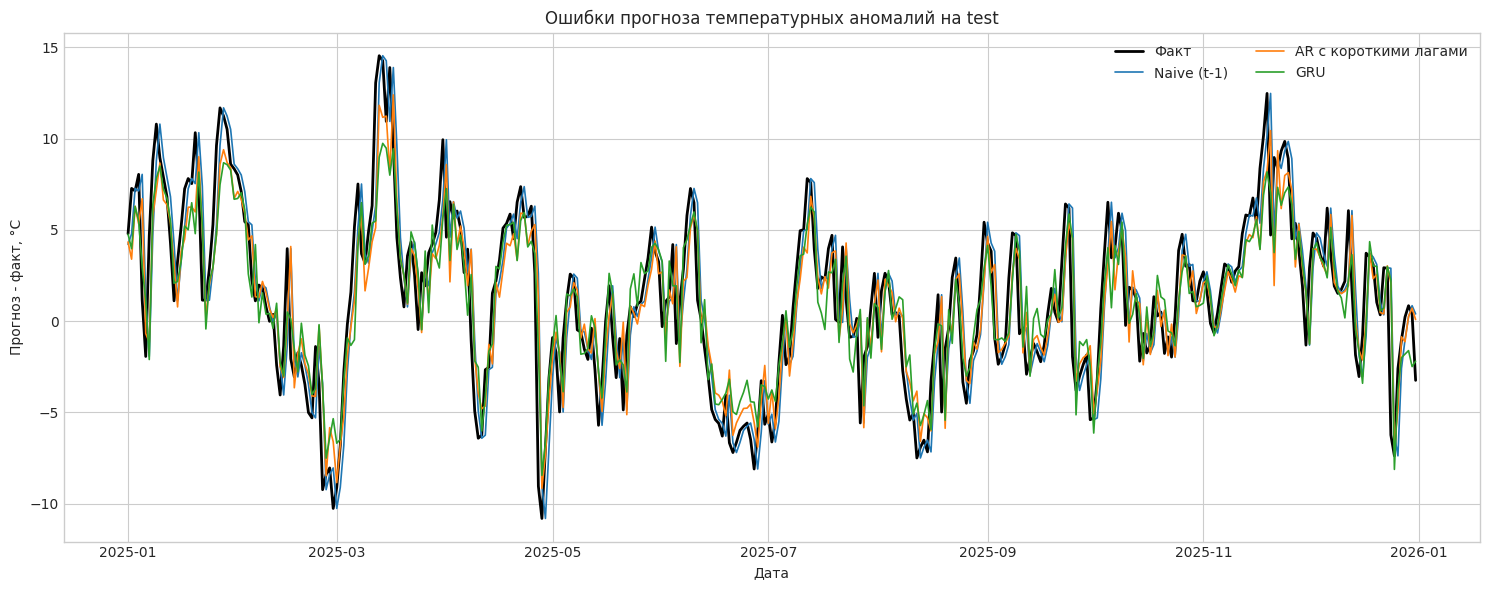

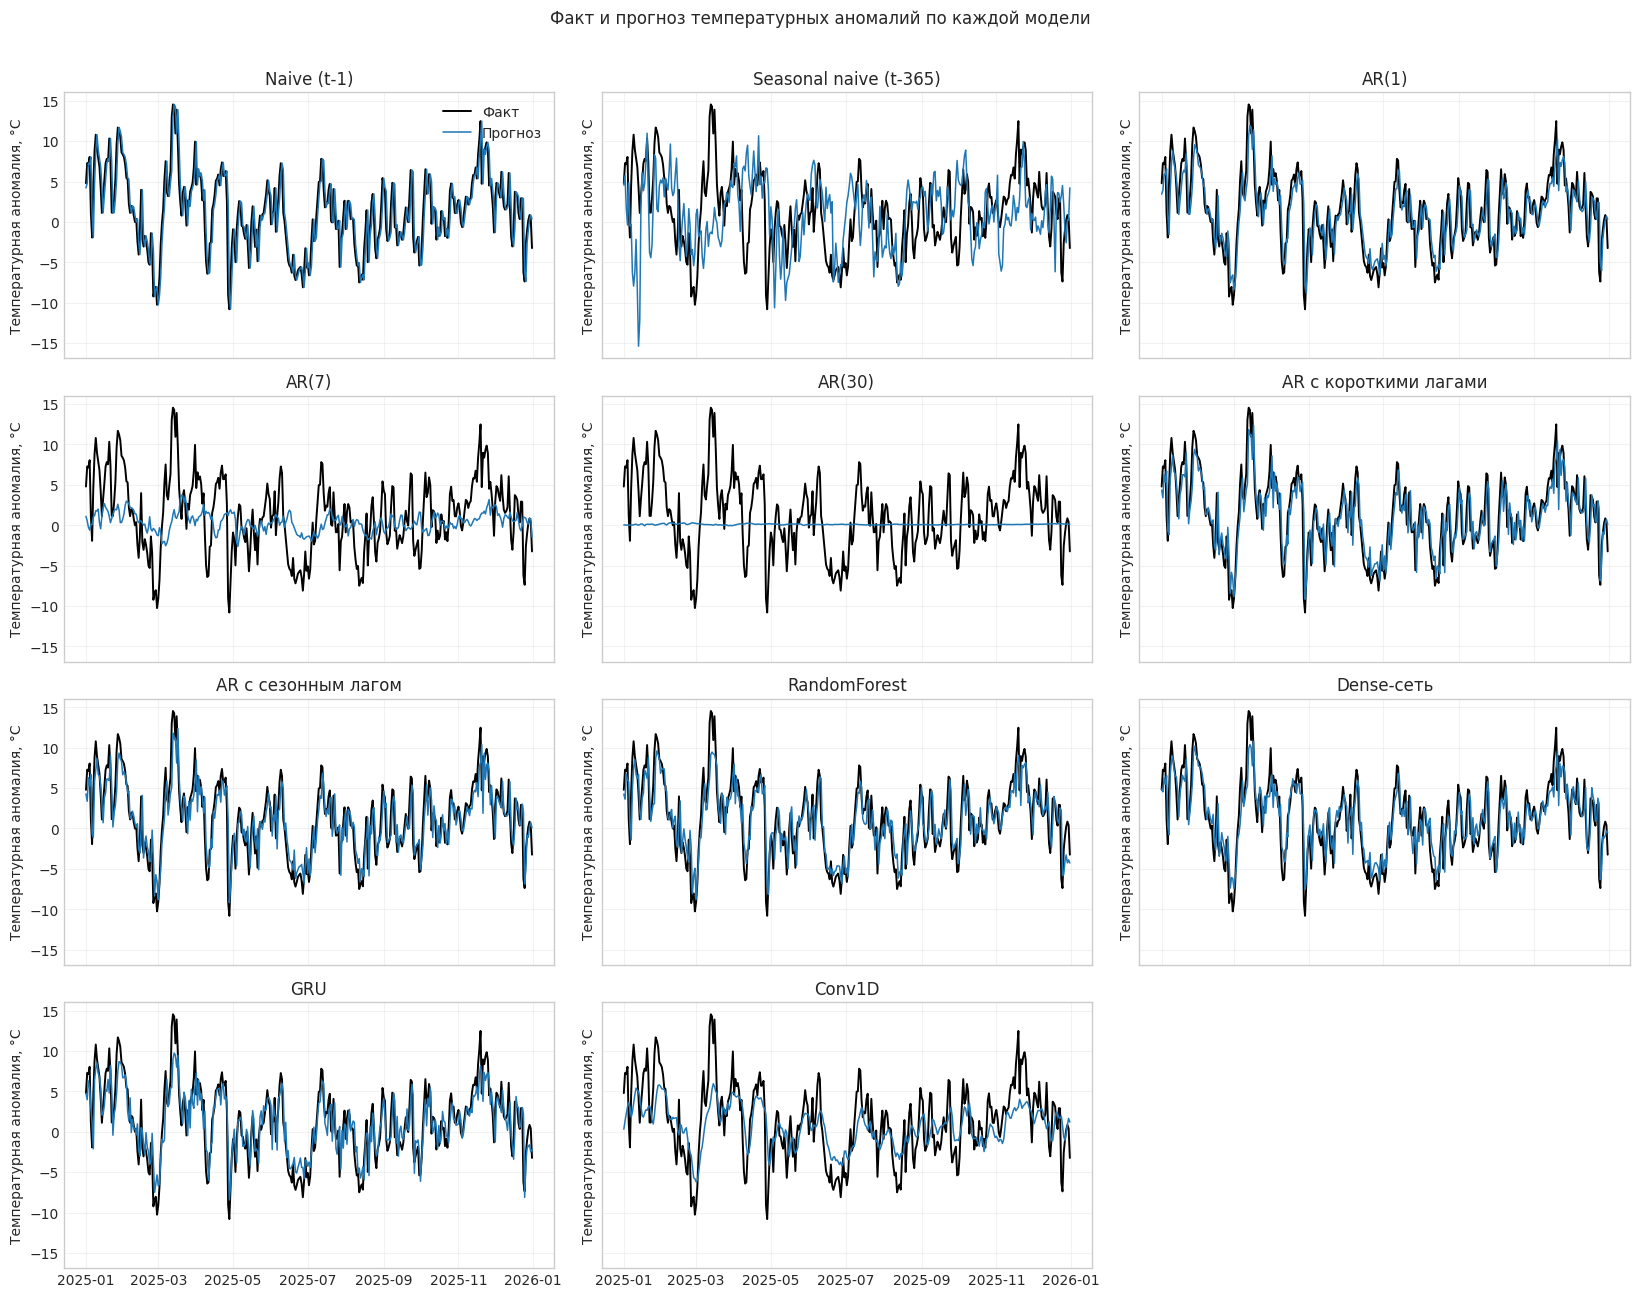

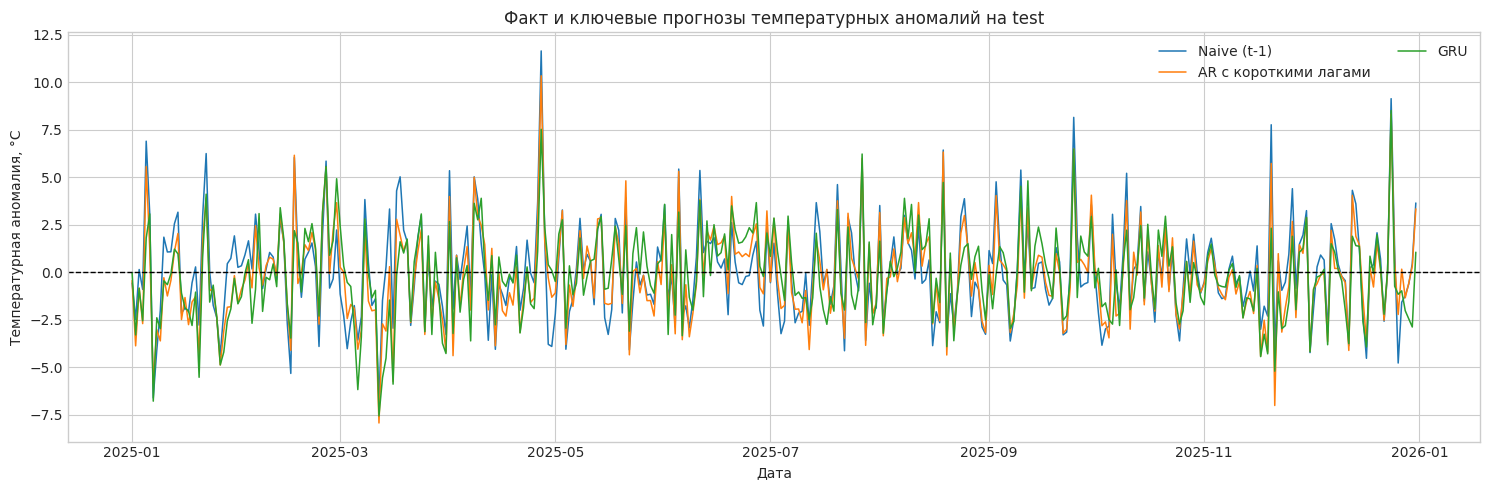

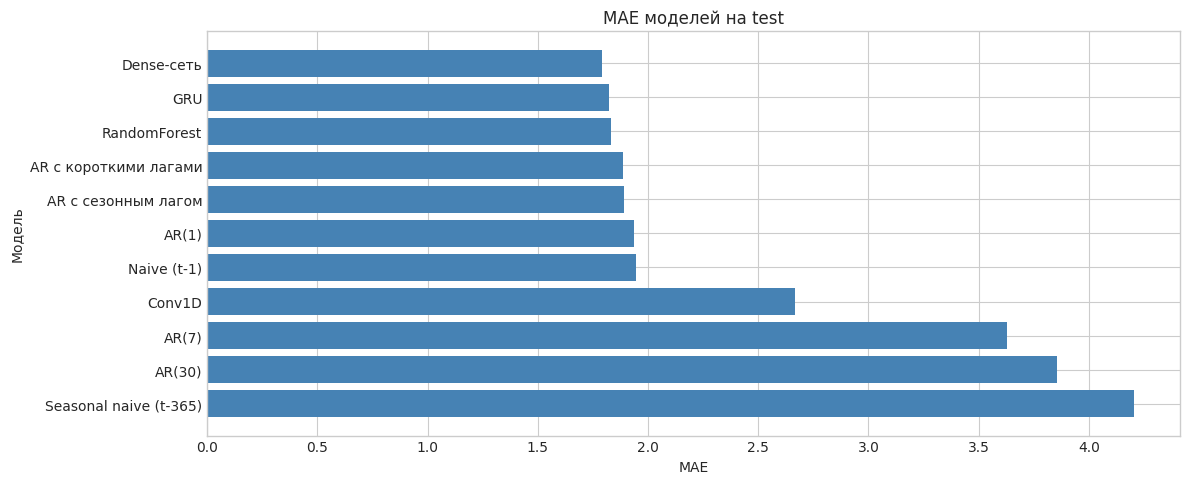

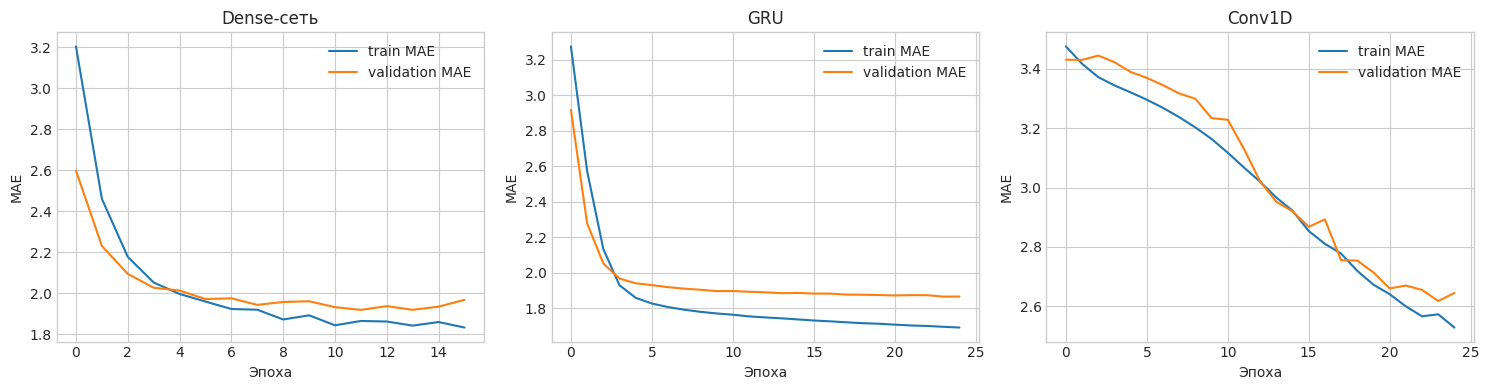

Кривые обучения сохранены в: /home/nochami/projects/0kursovaya/outputs/figures/02_neural_learning_curves.png
Обзорный график ключевых прогнозов сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_forecast_overview_key_models.png
Отдельные панели прогнозов сохранены в: /home/nochami/projects/0kursovaya/outputs/figures/02_forecast_small_multiples.png
График ошибок ключевых моделей сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_residuals_key_models.png
График MAE по моделям сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_mae_by_model.png


In [ ]:
forecast_overview_path = FIGURES_DIR / "02_forecast_overview_key_models.png"
forecast_small_multiples_path = FIGURES_DIR / "02_forecast_small_multiples.png"
residuals_key_models_path = FIGURES_DIR / "02_residuals_key_models.png"
mae_by_model_path = FIGURES_DIR / "02_mae_by_model.png"
learning_curves_path = FIGURES_DIR / "02_neural_learning_curves.png"


def load_table_or_frame(frame_name, table_path, parse_dates=None):
    if frame_name in globals():
        return globals()[frame_name].copy()
    if table_path.exists():
        return pd.read_csv(table_path, parse_dates=parse_dates)
    raise FileNotFoundError(
        f"Не найдены данные для графиков: нет DataFrame `{frame_name}` и файла `{table_path}`. "
        "Сначала выполните основной сценарий моделирования или проверьте файлы в outputs/tables."
    )


main_predictions_test = (
    main_result["test_predictions"].copy()
    if "main_result" in globals()
    else load_table_or_frame(
        "main_predictions_test",
        TABLES_DIR / "02_main_test_predictions.csv",
        parse_dates=["date"],
    )
)
main_validation_metrics_ready = load_table_or_frame(
    "main_validation_metrics",
    TABLES_DIR / "02_main_validation_metrics.csv",
)
main_test_metrics_ready = load_table_or_frame(
    "main_test_metrics",
    TABLES_DIR / "02_main_test_metrics.csv",
)

main_predictions_test["date"] = pd.to_datetime(main_predictions_test["date"])
model_columns = [
    column
    for column in main_predictions_test.columns
    if column not in {"date", TARGET_COLUMN, RAW_TARGET_COLUMN, "season"}
]
model_label_aliases = {"Seasonal AutoReg": "AR с сезонным лагом"}


def model_label(model_name):
    return model_label_aliases.get(model_name, model_name)


def best_available_model(metrics_frame, candidates):
    available = [model for model in candidates if model in model_columns]
    if not available:
        return None
    ranked = metrics_frame.loc[metrics_frame["model"].isin(available)].sort_values(
        ["mae", "rmse"]
    )
    if ranked.empty:
        return available[0]
    return ranked.iloc[0]["model"]


metric_source = "validation"
metric_frame_for_selection = main_validation_metrics_ready
if metric_frame_for_selection.empty:
    metric_source = "test"
    metric_frame_for_selection = main_test_metrics_ready
    display(
        Markdown(
            "Validation-метрики недоступны, поэтому ключевые модели временно выбраны по test-метрикам."
        )
    )

ar_candidates = [
    model
    for model in metric_frame_for_selection["model"]
    if str(model).startswith("AR")
]
if "Seasonal AutoReg" in metric_frame_for_selection["model"].values:
    ar_candidates.append("Seasonal AutoReg")
neural_candidates = ["Dense-сеть", "GRU", "Conv1D"]

best_ar_model = best_available_model(metric_frame_for_selection, ar_candidates)
best_neural_model = best_available_model(metric_frame_for_selection, neural_candidates)
key_models = []
for model_name in ["Naive (t-1)", best_ar_model, best_neural_model]:
    if (
        model_name is not None
        and model_name in model_columns
        and model_name not in key_models
    ):
        key_models.append(model_name)

if len(key_models) < 2:
    raise ValueError(
        "Недостаточно ключевых моделей для обзорного графика. Проверьте таблицы прогнозов и метрик."
    )

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(
    main_predictions_test["date"],
    main_predictions_test[TARGET_COLUMN],
    label="Факт",
    color="black",
    linewidth=2,
)
for model_name in key_models:
    ax.plot(
        main_predictions_test["date"],
        main_predictions_test[model_name],
        label=model_label(model_name),
        linewidth=1.2,
    )
ax.set_title("Факт и ключевые прогнозы температурных аномалий на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Температурная аномалия, °C")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(forecast_overview_path, dpi=200, bbox_inches="tight")
plt.show()

n_models = len(model_columns)
n_cols = 2 if n_models <= 6 else 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.5 * n_cols, 3.2 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
axes_flat = axes.ravel()
for ax, model_name in zip(axes_flat, model_columns):
    ax.plot(
        main_predictions_test["date"],
        main_predictions_test[TARGET_COLUMN],
        color="black",
        linewidth=1.4,
        label="Факт",
    )
    ax.plot(
        main_predictions_test["date"],
        main_predictions_test[model_name],
        linewidth=1.1,
        label="Прогноз",
    )
    ax.set_title(model_label(model_name))
    ax.set_ylabel("Температурная аномалия, °C")
    ax.grid(alpha=0.25)
for ax in axes_flat[n_models:]:
    ax.set_visible(False)
axes_flat[0].legend(loc="upper right")
fig.suptitle("Факт и прогноз температурных аномалий по каждой модели", y=1.01)
fig.tight_layout()
fig.savefig(forecast_small_multiples_path, dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
for model_name in key_models:
    residual = main_predictions_test[model_name] - main_predictions_test[TARGET_COLUMN]
    ax.plot(
        main_predictions_test["date"],
        residual,
        label=model_label(model_name),
        linewidth=1.1,
    )
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Ошибки прогноза температурных аномалий на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Прогноз - факт, °C")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(residuals_key_models_path, dpi=200, bbox_inches="tight")
plt.show()

mae_plot_frame = main_test_metrics_ready.sort_values("mae").copy()
mae_plot_frame["model_label"] = mae_plot_frame["model"].map(model_label)
fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(mae_plot_frame))))
ax.barh(mae_plot_frame["model_label"], mae_plot_frame["mae"], color="steelblue")
ax.invert_yaxis()
ax.set_title("MAE моделей на test")
ax.set_xlabel("MAE")
ax.set_ylabel("Модель")
fig.tight_layout()
fig.savefig(mae_by_model_path, dpi=200, bbox_inches="tight")
plt.show()

neural_histories = main_result["histories"] if "main_result" in globals() else {}
if neural_histories:
    fig, axes = plt.subplots(
        1, len(neural_histories), figsize=(5 * len(neural_histories), 4), squeeze=False
    )
    axes = axes.ravel()
    for ax, (model_name, history) in zip(axes, neural_histories.items()):
        ax.plot(history.history.get("loss", []), label="train MAE")
        ax.plot(history.history.get("val_loss", []), label="validation MAE")
        ax.set_title(model_name)
        ax.set_xlabel("Эпоха")
        ax.set_ylabel("MAE")
        ax.legend()
    fig.tight_layout()
    fig.savefig(learning_curves_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Кривые обучения сохранены в: {learning_curves_path}")
else:
    print(
        "Кривые обучения не обновлены: они доступны только после текущего запуска нейросетей."
    )

print(f"Обзорный график ключевых прогнозов сохранён в: {forecast_overview_path}")
print(f"Отдельные панели прогнозов сохранены в: {forecast_small_multiples_path}")
print(f"График ошибок ключевых моделей сохранён в: {residuals_key_models_path}")
print(f"График MAE по моделям сохранён в: {mae_by_model_path}")


## Шаг 10. Анализ ошибок по сезонам

Сезонный анализ помогает ответить на два исследовательских вопроса:

- в какие времена года модели ошибаются сильнее;
- у каких подходов заметнее систематическое смещение.


### Таблица сезонных ошибок

,model,season,mae_by_season,bias_by_season,rows
0,Conv1D,весна,4.102,-1.677,92
1,Conv1D,зима,3.784,-0.433,90
2,Conv1D,лето,3.136,0.387,92
3,Conv1D,осень,3.052,-1.761,91
4,Dense-сеть,весна,2.269,-0.968,92
5,Dense-сеть,зима,2.003,-0.335,90
6,Dense-сеть,лето,1.799,-0.347,92
7,Dense-сеть,осень,1.603,0.020,91
8,GRU,весна,1.935,-0.186,92
9,GRU,зима,1.763,-0.024,90


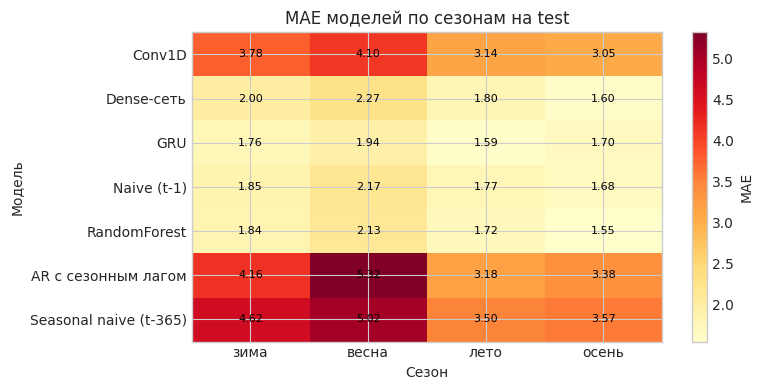

Тепловая карта сезонных ошибок сохранена в: /home/nochami/projects/0kursovaya/outputs/figures/02_mae_by_season_heatmap.png


In [13]:
seasonal_path = TABLES_DIR / "02_seasonal_error_analysis.csv"
season_heatmap_path = FIGURES_DIR / "02_mae_by_season_heatmap.png"

if "seasonal_summary" in globals():
    seasonal_summary_ready = seasonal_summary.copy()
elif seasonal_path.exists():
    seasonal_summary_ready = pd.read_csv(seasonal_path)
elif "main_predictions_test" in globals():
    seasonal_records = []
    for model_name in [
        column
        for column in main_predictions_test.columns
        if column not in {"date", TARGET_COLUMN, RAW_TARGET_COLUMN, "season"}
    ]:
        seasonal_records.append(
            pd.DataFrame(
                {
                    "date": main_predictions_test["date"],
                    "season": main_predictions_test["season"],
                    "model": model_name,
                    "absolute_error": (
                        main_predictions_test[model_name]
                        - main_predictions_test[TARGET_COLUMN]
                    ).abs(),
                    "residual": main_predictions_test[model_name]
                    - main_predictions_test[TARGET_COLUMN],
                }
            )
        )
    seasonal_error_df = pd.concat(seasonal_records, ignore_index=True)
    seasonal_summary_ready = (
        seasonal_error_df.groupby(["model", "season"])
        .agg(
            mae_by_season=("absolute_error", "mean"),
            bias_by_season=("residual", "mean"),
            rows=("absolute_error", "size"),
        )
        .reset_index()
    )
    seasonal_summary_ready.to_csv(seasonal_path, index=False)
else:
    seasonal_summary_ready = pd.DataFrame()
    print(
        f"Таблица сезонных ошибок не найдена: {seasonal_path}. Тепловая карта не построена."
    )

if not seasonal_summary_ready.empty:
    if "model_label" not in globals():
        model_label_aliases = {"Seasonal AutoReg": "AR с сезонным лагом"}

        def model_label(model_name):
            return model_label_aliases.get(model_name, model_name)

    display(Markdown("### Таблица сезонных ошибок"))
    display(seasonal_summary_ready.round(3))

    season_order = ["зима", "весна", "лето", "осень"]
    heatmap_frame = (
        seasonal_summary_ready.pivot(
            index="model", columns="season", values="mae_by_season"
        )
        .reindex(columns=season_order)
        .sort_index()
    )
    heatmap_frame = heatmap_frame.rename(index=model_label)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * len(heatmap_frame))))
    image = ax.imshow(heatmap_frame.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd")
    ax.set_xticks(np.arange(len(heatmap_frame.columns)))
    ax.set_xticklabels(heatmap_frame.columns)
    ax.set_yticks(np.arange(len(heatmap_frame.index)))
    ax.set_yticklabels(heatmap_frame.index)
    ax.set_title("MAE моделей по сезонам на test")
    ax.set_xlabel("Сезон")
    ax.set_ylabel("Модель")
    for row_idx in range(heatmap_frame.shape[0]):
        for col_idx in range(heatmap_frame.shape[1]):
            value = heatmap_frame.iloc[row_idx, col_idx]
            if pd.notna(value):
                ax.text(
                    col_idx,
                    row_idx,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=8,
                )
    fig.colorbar(image, ax=ax, label="MAE")
    fig.tight_layout()
    fig.savefig(season_heatmap_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Тепловая карта сезонных ошибок сохранена в: {season_heatmap_path}")


In [14]:
best_validation_model = main_validation_metrics.iloc[0]
best_test_model = main_test_metrics.iloc[0]
best_neural_test = (
    main_test_metrics.loc[
        main_test_metrics["model"].isin(["Dense-сеть", "GRU", "Conv1D"])
    ]
    .sort_values(["mae", "rmse"])
    .iloc[0]
)
histgb_test = main_test_metrics.loc[main_test_metrics["model"] == "RandomForest"].iloc[
    0
]

short_advantage = float(
    train_effect_summary.loc[
        train_effect_summary["scenario"] == scenario_order[0],
        "Преимущество лучшей нейросети над RandomForest",
    ].iloc[0]
)
long_advantage = float(
    train_effect_summary.loc[
        train_effect_summary["scenario"] == scenario_order[-1],
        "Преимущество лучшей нейросети над RandomForest",
    ].iloc[0]
)

if long_advantage < 0 and short_advantage < 0:
    train_effect_comment = (
        "В рассчитанных сценариях лучшая нейросеть показывает меньшую MAE, чем RandomForest. "
        "Этот вывод относится только к выбранному датасету, признакам и фиксированным периодам проверки."
    )
elif long_advantage > 0 and short_advantage > 0:
    train_effect_comment = (
        "В рассчитанных сценариях RandomForest показывает меньшую MAE, чем лучшая нейросеть. "
        "Это полезная точка сравнения, но не общий вывод о всех временных рядах и архитектурах."
    )
else:
    train_effect_comment = (
        "Относительное качество нейросетей меняется по мере роста train-истории: "
        "на части сценариев они лучше RandomForest, а на части уступают ему."
    )

if best_neural_test["mae"] < histgb_test["mae"]:
    neural_vs_ml_comment = (
        f"Лучшая нейросеть на test — **{best_neural_test['model']}** — обошла RandomForest "
        f"по MAE ({best_neural_test['mae']:.3f} против {histgb_test['mae']:.3f})."
    )
else:
    neural_vs_ml_comment = (
        f"Лучшая нейросеть на test — **{best_neural_test['model']}** — не смогла обойти RandomForest "
        f"по MAE ({best_neural_test['mae']:.3f} против {histgb_test['mae']:.3f})."
    )

summary_text = f"""
## Выводы

Лучшая модель на validation в основном сценарии: **{best_validation_model["model"]}**.

Лучшая модель на фиксированном test-интервале: **{best_test_model["model"]}**.

- {neural_vs_ml_comment}
- Нейросетевые модели используются как нелинейные бенчмарки для ряда температурных аномалий; их задача — проверить, дают ли более гибкие зависимости существенное улучшение относительно авторегрессионных моделей.
- `Seasonal naive` полезен как понятная сезонная точка отсчёта: он показывает, насколько трудно превзойти простое правило прошлого года.
- Авторегрессионные варианты дают статистические ориентиры с разной длиной памяти: от одного дня до сезонного лага порядка года.
- `RandomForest` используется как табличный нелинейный бенчмарк, а не как смысловой центр исследования.
- {train_effect_comment}
- По этим таблицам нельзя делать общий вывод, что нейросети всегда лучше классических моделей: качество зависит от признаков, длины истории, архитектуры и выбранного периода проверки.
- Сезонный анализ показывает, что качество модели полезно оценивать не только по одной усреднённой метрике: ошибки могут заметно отличаться между зимой, летом и переходными сезонами.
"""

display(Markdown(summary_text))



## Выводы

Лучшая модель на validation в основном сценарии: **GRU**.

Лучшая модель на фиксированном test-интервале: **Dense-сеть**.

- Лучшая нейросеть на test — **Dense-сеть** — обошла RandomForest по MAE (1.791 против 1.831).
- Нейросетевые модели используются как нелинейные бенчмарки для ряда температурных аномалий; их задача — проверить, дают ли более гибкие зависимости существенное улучшение относительно авторегрессионных моделей.
- `Seasonal naive` полезен как понятная сезонная точка отсчёта: он показывает, насколько трудно превзойти простое правило прошлого года.
- Авторегрессионные варианты дают статистические ориентиры с разной длиной памяти: от одного дня до сезонного лага порядка года.
- `RandomForest` используется как табличный нелинейный бенчмарк, а не как смысловой центр исследования.
- В рассчитанных сценариях лучшая нейросеть показывает меньшую MAE, чем RandomForest. Этот вывод относится только к выбранному датасету, признакам и фиксированным периодам проверки.
- По этим таблицам нельзя делать общий вывод, что нейросети всегда лучше классических моделей: качество зависит от признаков, длины истории, архитектуры и выбранного периода проверки.
- Сезонный анализ показывает, что качество модели полезно оценивать не только по одной усреднённой метрике: ошибки могут заметно отличаться между зимой, летом и переходными сезонами.
